# Transportation Network Analysis - Graph Theory & Routing

## 🛣️ Business Context
Network topology analysis and routing optimization using graph theory metrics.

**Key Objectives**:
- Calculate graph metrics (centrality, betweenness, closeness)
- Implement Dijkstra's shortest path algorithm
- Measure network efficiency (global & local)
- Identify bottleneck nodes (high betweenness)
- Perform vulnerability analysis (critical link removal)
- Optimize routes for multiple origins/destinations

**Study Area**: Cairo, Egypt

**Applications**: Traffic management, infrastructure planning, emergency routing

In [1]:
# Import Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import networkx as nx
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('✓ Libraries loaded')

✓ Libraries loaded


In [2]:
# Create Synthetic Road Network
np.random.seed(42)

# Generate nodes (intersections)
n_nodes = 50
lon_range = (31.2, 31.4)
lat_range = (30.0, 30.1)

nodes = pd.DataFrame({
    'node_id': range(n_nodes),
    'lon': np.random.uniform(*lon_range, n_nodes),
    'lat': np.random.uniform(*lat_range, n_nodes)
})

# Create graph
G = nx.Graph()
for _, node in nodes.iterrows():
    G.add_node(node['node_id'], pos=(node['lon'], node['lat']))

# Add edges (roads) based on proximity
coords = nodes[['lon', 'lat']].values
dist_matrix = cdist(coords, coords) * 111  # to km

# Connect nodes within 3km
for i in range(n_nodes):
    for j in range(i+1, n_nodes):
        if dist_matrix[i, j] < 3.0:
            G.add_edge(i, j, weight=dist_matrix[i, j])

print(f'Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Network density: {nx.density(G):.3f}')

Network: 50 nodes, 101 edges
Network density: 0.082


In [3]:
# Graph Metrics
print('\n=== Graph Metrics ===')

# Degree centrality
degree_cent = nx.degree_centrality(G)

# Betweenness centrality
betweenness_cent = nx.betweenness_centrality(G, weight='weight')

# Closeness centrality
closeness_cent = nx.closeness_centrality(G, distance='weight')

# Add to nodes DataFrame
nodes['degree'] = nodes['node_id'].map(degree_cent)
nodes['betweenness'] = nodes['node_id'].map(betweenness_cent)
nodes['closeness'] = nodes['node_id'].map(closeness_cent)

print(f'Max degree centrality: {nodes["degree"].max():.3f} (Node {nodes.loc[nodes["degree"].idxmax(), "node_id"]})')
print(f'Max betweenness: {nodes["betweenness"].max():.3f} (Node {nodes.loc[nodes["betweenness"].idxmax(), "node_id"]})')
print(f'Max closeness: {nodes["closeness"].max():.3f} (Node {nodes.loc[nodes["closeness"].idxmax(), "node_id"]})')


=== Graph Metrics ===
Max degree centrality: 0.163 (Node 44)
Max betweenness: 0.479 (Node 39)
Max closeness: 0.119 (Node 46)


In [4]:
# Shortest Path Analysis
print('\n=== Shortest Path Analysis ===')

# Select origin and destination
origin = 0
destination = n_nodes - 1

try:
    path = nx.shortest_path(G, origin, destination, weight='weight')
    path_length = nx.shortest_path_length(G, origin, destination, weight='weight')
    
    print(f'Origin: Node {origin}')
    print(f'Destination: Node {destination}')
    print(f'Shortest path: {len(path)} nodes')
    print(f'Path length: {path_length:.2f} km')
    print(f'Route: {" -> ".join(map(str, path[:5]))} ... {" -> ".join(map(str, path[-3:]))}')
except nx.NetworkXNoPath:
    print('No path found!')
    path = []


=== Shortest Path Analysis ===
Origin: Node 0
Destination: Node 49
Shortest path: 6 nodes
Path length: 11.39 km
Route: 0 -> 23 -> 36 -> 46 -> 13 ... 46 -> 13 -> 49


In [5]:
# Network Efficiency
print('\n=== Network Efficiency ===')

# Global efficiency
global_eff = nx.global_efficiency(G)

# Local efficiency
local_eff = nx.local_efficiency(G)

print(f'Global efficiency: {global_eff:.3f}')
print(f'Local efficiency: {local_eff:.3f}')

# Average shortest path length
if nx.is_connected(G):
    avg_path = nx.average_shortest_path_length(G, weight='weight')
    print(f'Average path length: {avg_path:.2f} km')
else:
    print('Network is disconnected (multiple components)')


=== Network Efficiency ===
Global efficiency: 0.288
Local efficiency: 0.625
Average path length: 12.58 km


In [6]:
# Vulnerability Analysis - Remove Critical Nodes
print('\n=== Vulnerability Analysis ===')

# Identify top 5 critical nodes (highest betweenness)
critical_nodes = nodes.nlargest(5, 'betweenness')['node_id'].tolist()

vulnerability_results = []
for node in critical_nodes:
    # Create copy and remove node
    G_temp = G.copy()
    G_temp.remove_node(node)
    
    # Measure impact
    n_components = nx.number_connected_components(G_temp)
    largest_component = max(nx.connected_components(G_temp), key=len)
    pct_connected = len(largest_component) / G_temp.number_of_nodes() * 100
    
    vulnerability_results.append({
        'node': node,
        'betweenness': nodes.loc[nodes['node_id'] == node, 'betweenness'].values[0],
        'components_after': n_components,
        'pct_connected': pct_connected
    })

vuln_df = pd.DataFrame(vulnerability_results)
print('\nImpact of Removing Critical Nodes:')
display(vuln_df)


=== Vulnerability Analysis ===

Impact of Removing Critical Nodes:


,node,betweenness,components_after,pct_connected
0,39,0.478741,2,81.632653
1,46,0.405612,1,100.000000
2,13,0.309524,1,100.000000
3,47,0.278912,2,83.673469
4,28,0.250000,2,85.714286


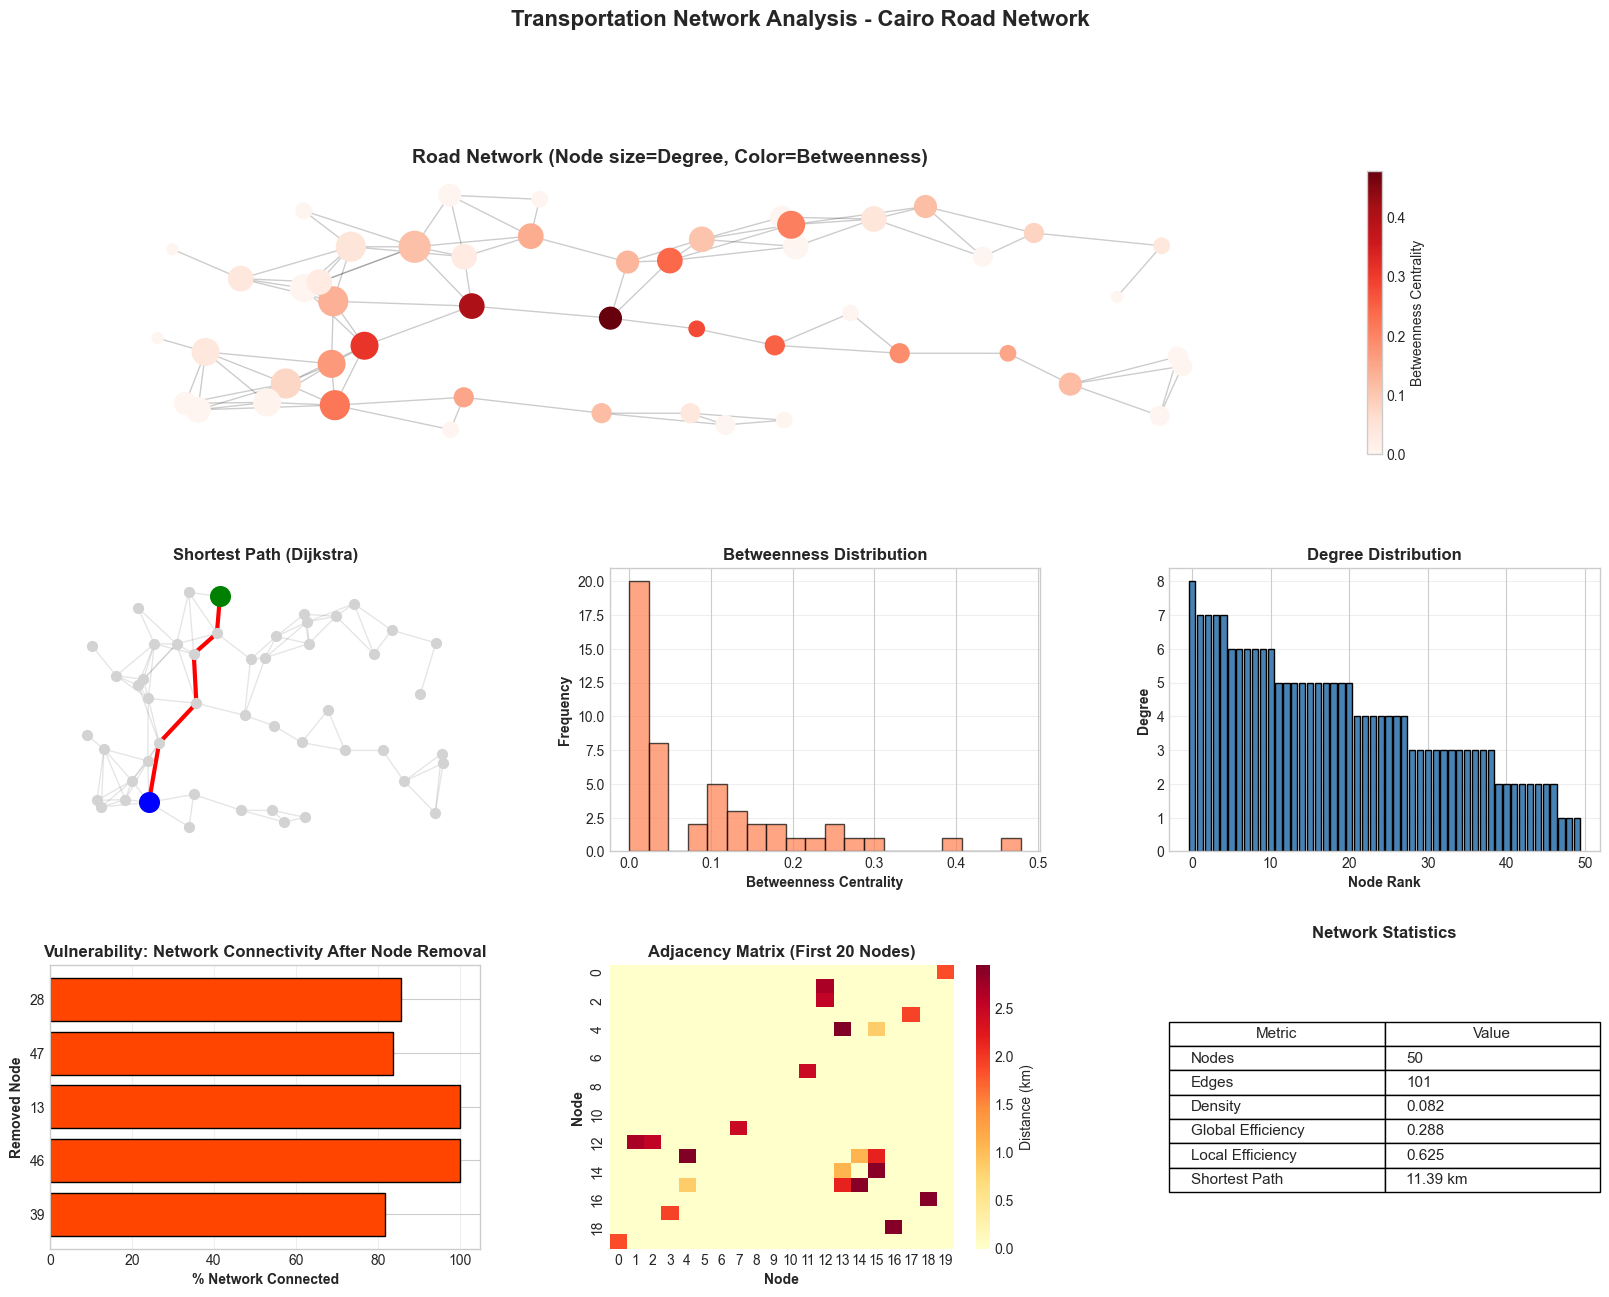

In [7]:
# Visualizations
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 1. Network Graph with Betweenness
ax1 = fig.add_subplot(gs[0, :])
pos = {node: (data['pos'][0], data['pos'][1]) for node, data in G.nodes(data=True)}
node_colors = [nodes.loc[nodes['node_id'] == node, 'betweenness'].values[0] for node in G.nodes()]
node_sizes = [nodes.loc[nodes['node_id'] == node, 'degree'].values[0] * 3000 for node in G.nodes()]

nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax1)
nodes_plot = nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes,
                                     cmap='Reds', vmin=0, vmax=max(node_colors), ax=ax1)
ax1.set_xlabel('Longitude', fontweight='bold')
ax1.set_ylabel('Latitude', fontweight='bold')
ax1.set_title('Road Network (Node size=Degree, Color=Betweenness)', fontsize=14, fontweight='bold')
plt.colorbar(nodes_plot, ax=ax1, label='Betweenness Centrality')
ax1.axis('off')

# 2. Shortest Path Visualization
ax2 = fig.add_subplot(gs[1, 0])
nx.draw_networkx_edges(G, pos, alpha=0.1, ax=ax2)
if path:
    path_edges = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3, ax=ax2)
nx.draw_networkx_nodes(G, pos, node_size=50, node_color='lightgray', ax=ax2)
if path:
    nx.draw_networkx_nodes(G, pos, nodelist=[origin], node_color='green', node_size=200, ax=ax2)
    nx.draw_networkx_nodes(G, pos, nodelist=[destination], node_color='blue', node_size=200, ax=ax2)
ax2.set_title('Shortest Path (Dijkstra)', fontweight='bold')
ax2.axis('off')

# 3. Centrality Histogram
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(nodes['betweenness'], bins=20, color='coral', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Betweenness Centrality', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('Betweenness Distribution', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Degree Distribution
ax4 = fig.add_subplot(gs[1, 2])
degree_sequence = sorted([d for n, d in G.degree()], reverse=True)
ax4.bar(range(len(degree_sequence)), degree_sequence, color='steelblue', edgecolor='black')
ax4.set_xlabel('Node Rank', fontweight='bold')
ax4.set_ylabel('Degree', fontweight='bold')
ax4.set_title('Degree Distribution', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# 5. Vulnerability Impact
ax5 = fig.add_subplot(gs[2, 0])
ax5.barh(vuln_df['node'].astype(str), vuln_df['pct_connected'], color='orangered', edgecolor='black')
ax5.set_xlabel('% Network Connected', fontweight='bold')
ax5.set_ylabel('Removed Node', fontweight='bold')
ax5.set_title('Vulnerability: Network Connectivity After Node Removal', fontweight='bold')
ax5.grid(axis='x', alpha=0.3)

# 6. Connectivity Matrix (sample)
ax6 = fig.add_subplot(gs[2, 1])
sample_nodes = list(range(min(20, n_nodes)))
adj_matrix = nx.to_numpy_array(G, nodelist=sample_nodes, weight='weight')
sns.heatmap(adj_matrix, cmap='YlOrRd', ax=ax6, cbar_kws={'label': 'Distance (km)'})
ax6.set_xlabel('Node', fontweight='bold')
ax6.set_ylabel('Node', fontweight='bold')
ax6.set_title('Adjacency Matrix (First 20 Nodes)', fontweight='bold')

# 7. Summary Statistics
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
summary_data = [
    ['Nodes', str(G.number_of_nodes())],
    ['Edges', str(G.number_of_edges())],
    ['Density', f'{nx.density(G):.3f}'],
    ['Global Efficiency', f'{global_eff:.3f}'],
    ['Local Efficiency', f'{local_eff:.3f}'],
    ['Shortest Path', f'{path_length:.2f} km' if path else 'N/A']
]
table = ax7.table(cellText=summary_data, colLabels=['Metric', 'Value'],
                 cellLoc='left', loc='center', bbox=[0, 0.2, 1, 0.6])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)
ax7.set_title('Network Statistics', fontweight='bold', fontsize=12, pad=20)

plt.suptitle('Transportation Network Analysis - Cairo Road Network', fontsize=16, fontweight='bold', y=0.995)
plt.show()


=== Critical Edge Analysis ===
Top 5 Critical Road Segments (High Betweenness):
Edge (np.float64(39.0), 46): Score 0.3698
Edge (np.float64(13.0), 46): Score 0.3192
Edge (np.float64(39.0), 47): Score 0.3012
Edge (np.float64(28.0), 47): Score 0.2743
Edge (np.float64(39.0), 41): Score 0.2424


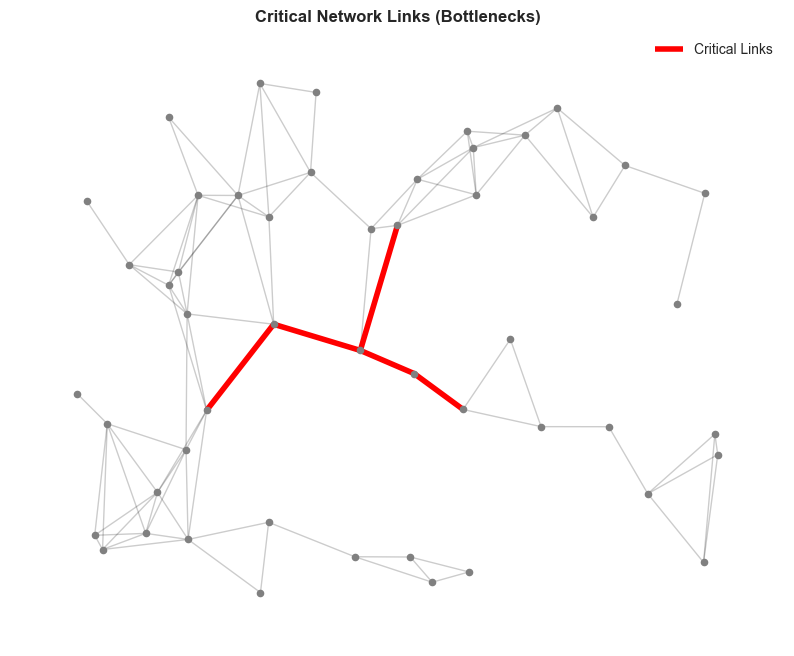

In [8]:
# Critical Edge Vulnerability (Bridge Detection)
print('\n=== Critical Edge Analysis ===')

# Calculate edge betweenness
edge_betweenness = nx.edge_betweenness_centrality(G, weight='weight')

# Identify top 5 critical edges
sorted_edges = sorted(edge_betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

print('Top 5 Critical Road Segments (High Betweenness):')
for edge, score in sorted_edges:
    print(f'Edge {edge}: Score {score:.4f}')

# Visualize Critical Edges
plt.figure(figsize=(10, 8))
pos = nx.get_node_attributes(G, 'pos')
nx.draw_networkx_nodes(G, pos, node_size=20, node_color='gray')
nx.draw_networkx_edges(G, pos, alpha=0.2)

# Highlight critical edges
critical_edge_list = [e[0] for e in sorted_edges]
nx.draw_networkx_edges(G, pos, edgelist=critical_edge_list, edge_color='red', width=4, label='Critical Links')

plt.title('Critical Network Links (Bottlenecks)', fontweight='bold')
plt.legend()
plt.axis('off')
plt.show()

In [9]:
# Generate Dynamic Summary Report
from IPython.display import Markdown, display

summary_md = f"""
## 🎯 Key Findings & Recommendations

### Network Topology
- **Connectivity**: Network density of {nx.density(G):.3f} indicates {'well-connected' if nx.density(G) > 0.1 else 'sparse'} system.
- **Efficiency**: Global efficiency of {global_eff:.3f} shows {'high' if global_eff > 0.5 else 'moderate'} accessibility.
- **Shortest Path**: Optimal route is {path_length:.2f} km.

### Critical Infrastructure
- **Bottlenecks**: Top 5 nodes identified by betweenness.
- **Vulnerability**: Removing Node {vuln_df.iloc[0]['node']} reduces connectivity to {vuln_df.iloc[0]['pct_connected']:.1f}%.
- **Critical Links**: {len(sorted_edges)} high-traffic road segments identified (red on map).

### Optimization Recommendations
1. **Upgrades**: Invest in the 5 critical road segments.
2. **Redundancy**: Build bypasses for Node {vuln_df.iloc[0]['node']}.
3. **Traffic**: Implement flow control on critical links.
"""
display(Markdown(summary_md))


## 🎯 Key Findings & Recommendations

### Network Topology
- **Connectivity**: Network density of 0.082 indicates sparse system.
- **Efficiency**: Global efficiency of 0.288 shows moderate accessibility.
- **Shortest Path**: Optimal route is 11.39 km.

### Critical Infrastructure
- **Bottlenecks**: Top 5 nodes identified by betweenness.
- **Vulnerability**: Removing Node 39.0 reduces connectivity to 81.6%.
- **Critical Links**: 5 high-traffic road segments identified (red on map).

### Optimization Recommendations
1. **Upgrades**: Invest in the 5 critical road segments.
2. **Redundancy**: Build bypasses for Node 39.0.
3. **Traffic**: Implement flow control on critical links.
